# K-Means


In [1]:
import pandas as pd


In [2]:
url = "https://raw.githubusercontent.com/iPriyadarshi/MachineLearning-BCS4706/main/dataset/logistics_2000_dataset.csv"
df = pd.read_csv(url)


In [3]:
df.head()


,latitude,longitude,distance_km,demand,accessibility
0,26.804834,80.864214,9.883383,42,0.091883
1,27.012257,80.858912,20.175776,21,0.047224
2,26.933518,81.096252,17.222248,37,0.054878
3,26.885517,80.859837,9.776628,27,0.092793
4,26.726167,80.867902,16.000369,29,0.058822


In [4]:
df.shape


(2000, 5)

In [5]:
df.columns


Index(['latitude', 'longitude', 'distance_km', 'demand', 'accessibility'], dtype='str')

In [6]:
# Feature Selection

X = df[['latitude', 'longitude']]


In [7]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
X


,latitude,longitude
0,26.804834,80.864214
1,27.012257,80.858912
2,26.933518,81.096252
3,26.885517,80.859837
4,26.726167,80.867902
...,...,...
1995,26.906504,80.929159
1996,27.014381,80.890384
1997,26.694825,80.912046
1998,26.690540,80.960779


## Elbow Method


In [9]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1,15)

for k in K_range:
    kmeans  = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


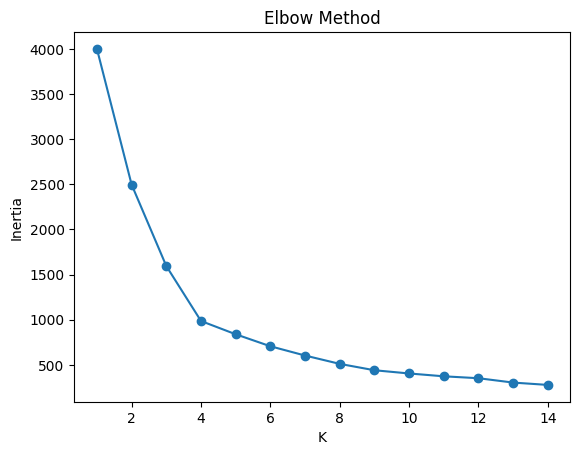

In [10]:
import matplotlib.pyplot as plt

plt.plot(K_range,inertia,marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [11]:
kmeans  = KMeans(n_clusters=4,random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

centers = kmeans.cluster_centers_


In [12]:
centers_original = scaler.inverse_transform(centers)


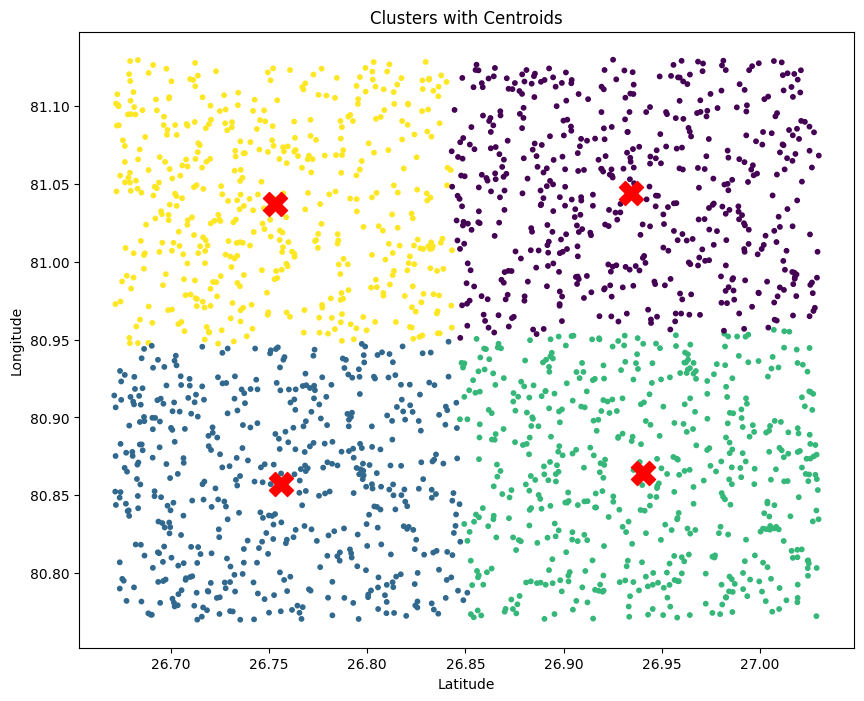

In [13]:
plt.figure(figsize=(10,8))

# datapoints
plt.scatter(df['latitude'],df['longitude'],c=df['cluster'],s=10)

# centroids
plt.scatter(centers_original[:,0],centers_original[:,1],s=300,marker='X',c='red')

plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Clusters with Centroids")
plt.show()


In [14]:
# Cluster Summary

summary = df.groupby('cluster').agg({
    'distance_km' : 'mean',
    'demand' : 'mean',
    'accessibility': 'mean'
})

print(summary)


         distance_km     demand  accessibility
cluster                                       
0          14.334152  25.105882       0.081214
1          15.005420  24.896552       0.073825
2          14.287686  24.873585       0.084085
3          14.823429  25.321199       0.077572
